In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

In [2]:
number_of_samples = 1200
low = -1
high = 0
s = np.random.uniform(low, high, number_of_samples)

print("uniform :", s)

uniform : [-0.83465051 -0.49283458 -0.95137611 ... -0.74090304 -0.06469077
 -0.64554755]


In [3]:
# all values of s are within the half open interval [-1, 0] :
print(np.all(s >= -1) and np.all(s < 0))

True


In [ ]:
"""
The histogram of the samples, created with the uniform function in our previous example, 
looks like this:
"""

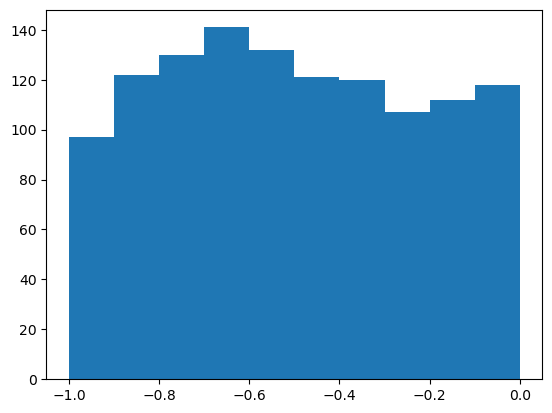

In [4]:
plt.hist(s)
plt.show()

In [ ]:
""
The next function we will look at is 'binomial' from numpy.binomial:
binomial(n, p, size=None)

It draws samples from a binomial distribution with specified parameters, n trials and probability 
p of success where n is an integer >= 0 and p is a float in the interval [0,1]. 
( n may be input as a float, but it is truncated to an integer in use)

"""

binomial :  [41 55 48 ... 45 50 49]


(array([  9.,  54., 108., 249., 311., 265., 142.,  43.,  14.,   5.]),
 array([36. , 39.1, 42.2, 45.3, 48.4, 51.5, 54.6, 57.7, 60.8, 63.9, 67. ]),
 <BarContainer object of 10 artists>)

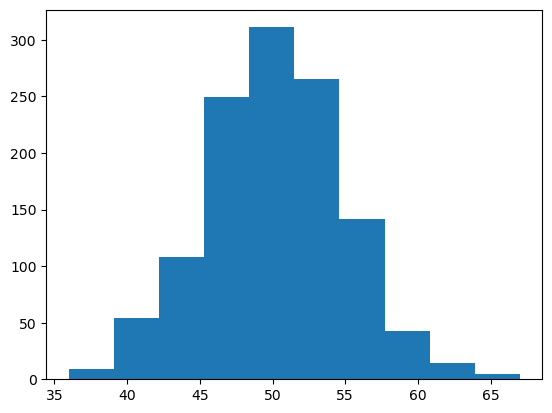

In [5]:
s = np.random.binomial(100, 0.5, 1200)
print("binomial : ", s)

plt.hist(s)
# plt.show()

In [ ]:
"""
We like to create random numbers with a normal distribution, but the numbers have to be bounded. 
This is not the case with np.random.normal(), because it doesn't offer any bound parameter.

We can use truncnorm from scipy.stats for this purpose.

The standard form of this distribution is a standard normal truncated to the range [a, b] — notice
that a and b are defined over the domain of the standard normal. To convert clip values for a 
specific mean and standard deviation, use:

a, b = (myclip_a - my_mean) / my_std, (myclip_b - my_mean) / my_std
"""

(array([104., 101.,  98.,  95., 109., 105., 108., 103.,  84.,  93.]),
 array([-0.66470391, -0.53157462, -0.39844532, -0.26531603, -0.13218673,
         0.00094256,  0.13407186,  0.26720115,  0.40033045,  0.53345974,
         0.66658904]),
 <BarContainer object of 10 artists>)

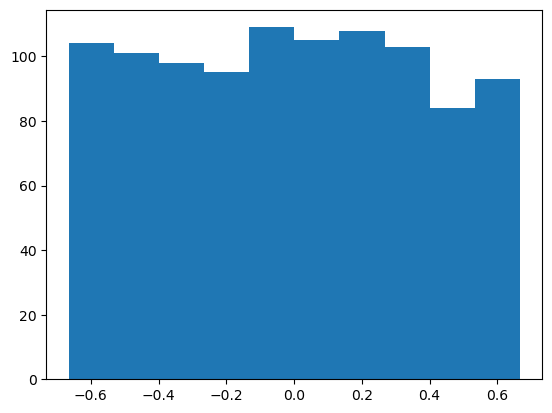

In [6]:
s = truncnorm(a=-2/3., b=2/3., scale=1, loc=0).rvs(size=1000)
# print("truncorm : ", s)

plt.hist(s)
# plt.show()

In [ ]:
"""
The function 'truncnorm' is difficult to use. To make life easier, we define a function 
truncated_normal in the following to facilitate this task:
"""

X : <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D61F24E520>


(array([ 676.,  833., 1029., 1160., 1220., 1215., 1225., 1072.,  851.,
         719.]),
 array([-4.99865111e-01, -3.99898929e-01, -2.99932747e-01, -1.99966565e-01,
        -1.00000383e-01, -3.42004848e-05,  9.99319816e-02,  1.99898164e-01,
         2.99864346e-01,  3.99830528e-01,  4.99796710e-01]),
 <BarContainer object of 10 artists>)

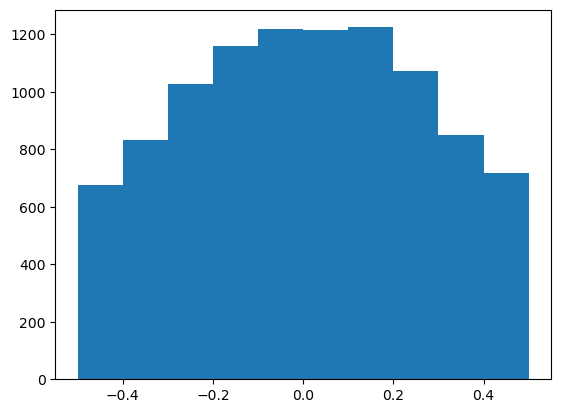

In [7]:
def truncated_normal(mean=0, sd=1, low=0, upp=10):
    return truncnorm((low - mean) / sd, (upp - mean) / sd, loc=mean, scale=sd)

X = truncated_normal(mean=0, sd=0.4, low=-0.5, upp=0.5)
print("X :", X)
s = X.rvs(10000)

plt.hist(s)
# plt.show()

(array([1.31510735e-04, 0.00000000e+00, 5.26042941e-04, 6.70704750e-03,
        3.81381132e-02, 1.53473028e-01, 3.17203894e-01, 3.98740549e-01,
        2.86561892e-01, 1.13625275e-01]),
 array([2.39365768, 3.15405188, 3.91444607, 4.67484027, 5.43523447,
        6.19562867, 6.95602286, 7.71641706, 8.47681126, 9.23720546,
        9.99759965]),
 <BarContainer object of 10 artists>)

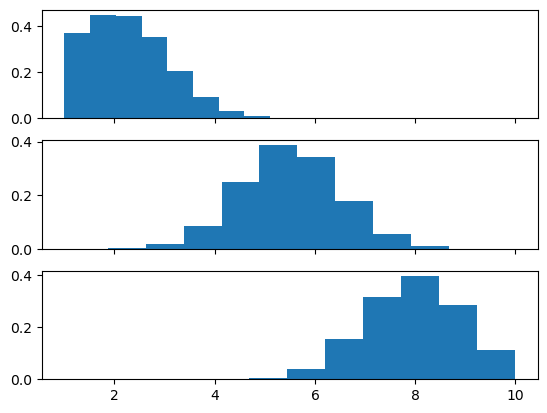

In [8]:
X1 = truncated_normal(mean=2, sd=1, low=1, upp=10)
X2 = truncated_normal(mean=5.5, sd=1, low=1, upp=10)
X3 = truncated_normal(mean=8, sd=1, low=1, upp=10)

ig, ax = plt.subplots(3, sharex=True)
ax[0].hist(X1.rvs(10000), density=True)
ax[1].hist(X2.rvs(10000), density=True)
ax[2].hist(X3.rvs(10000), density=True)
# plt.show()

In [ ]:
"""
We will create the link weights matrix now. truncated_normal is ideal for this purpose. It is a 
good idea to choose random values from within the interval

( − 1 /√n , 1 /√n )
where n denotes the number of input nodes.

So we can create our "wih" matrix with:
"""

In [9]:
no_of_input_nodes = 3
no_of_hidden_nodes = 4

rad = 1 / np.sqrt(no_of_input_nodes)

X = truncated_normal(mean=2, sd=1, low=-rad, upp=rad)
wih = X.rvs((no_of_hidden_nodes, no_of_input_nodes))
print("wih :", wih)

wih : [[ 0.22061476  0.05215888 -0.25862242]
 [ 0.29977333  0.38191174 -0.17086664]
 [ 0.41139341  0.54512984 -0.01088296]
 [-0.17266099  0.27419568  0.42888647]]


In [ ]:
"""
Similarly, we can now define the "who" weight matrix:
"""

In [10]:
no_of_hidden_nodes = 4
no_of_output_nodes = 2

rad = 1 / np.sqrt(no_of_hidden_nodes)

X = truncated_normal(mean=2, sd=1, low=-rad, upp=rad)
print("X : ", X)

who = X.rvs((no_of_output_nodes, no_of_hidden_nodes))
print("who : ", who)

X :  <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D6226516D0>
who :  [[ 0.22484005  0.45759573  0.09351696  0.46847726]
 [ 0.13188738  0.10583663  0.15234335 -0.49246271]]
